In [ ]:
import matplotlib.pyplot as plt
import pickle
import numpy as np

In [ ]:
# Load precomputed data
with open('figure1c_data.pkl', 'rb') as f:
    melste, maelste, melstm, maelstm, melst, maelst = pickle.load(f)

<>:63: SyntaxWarning: invalid escape sequence '\d'
<>:63: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_2197539/1487486019.py:63: SyntaxWarning: invalid escape sequence '\d'
  plt.title('(c) $R_{size}$ errors (Red: ERA5; Orange: 1.0$\degree$ ERA5; Blue: MERRA2)',fontsize=16,pad=15)


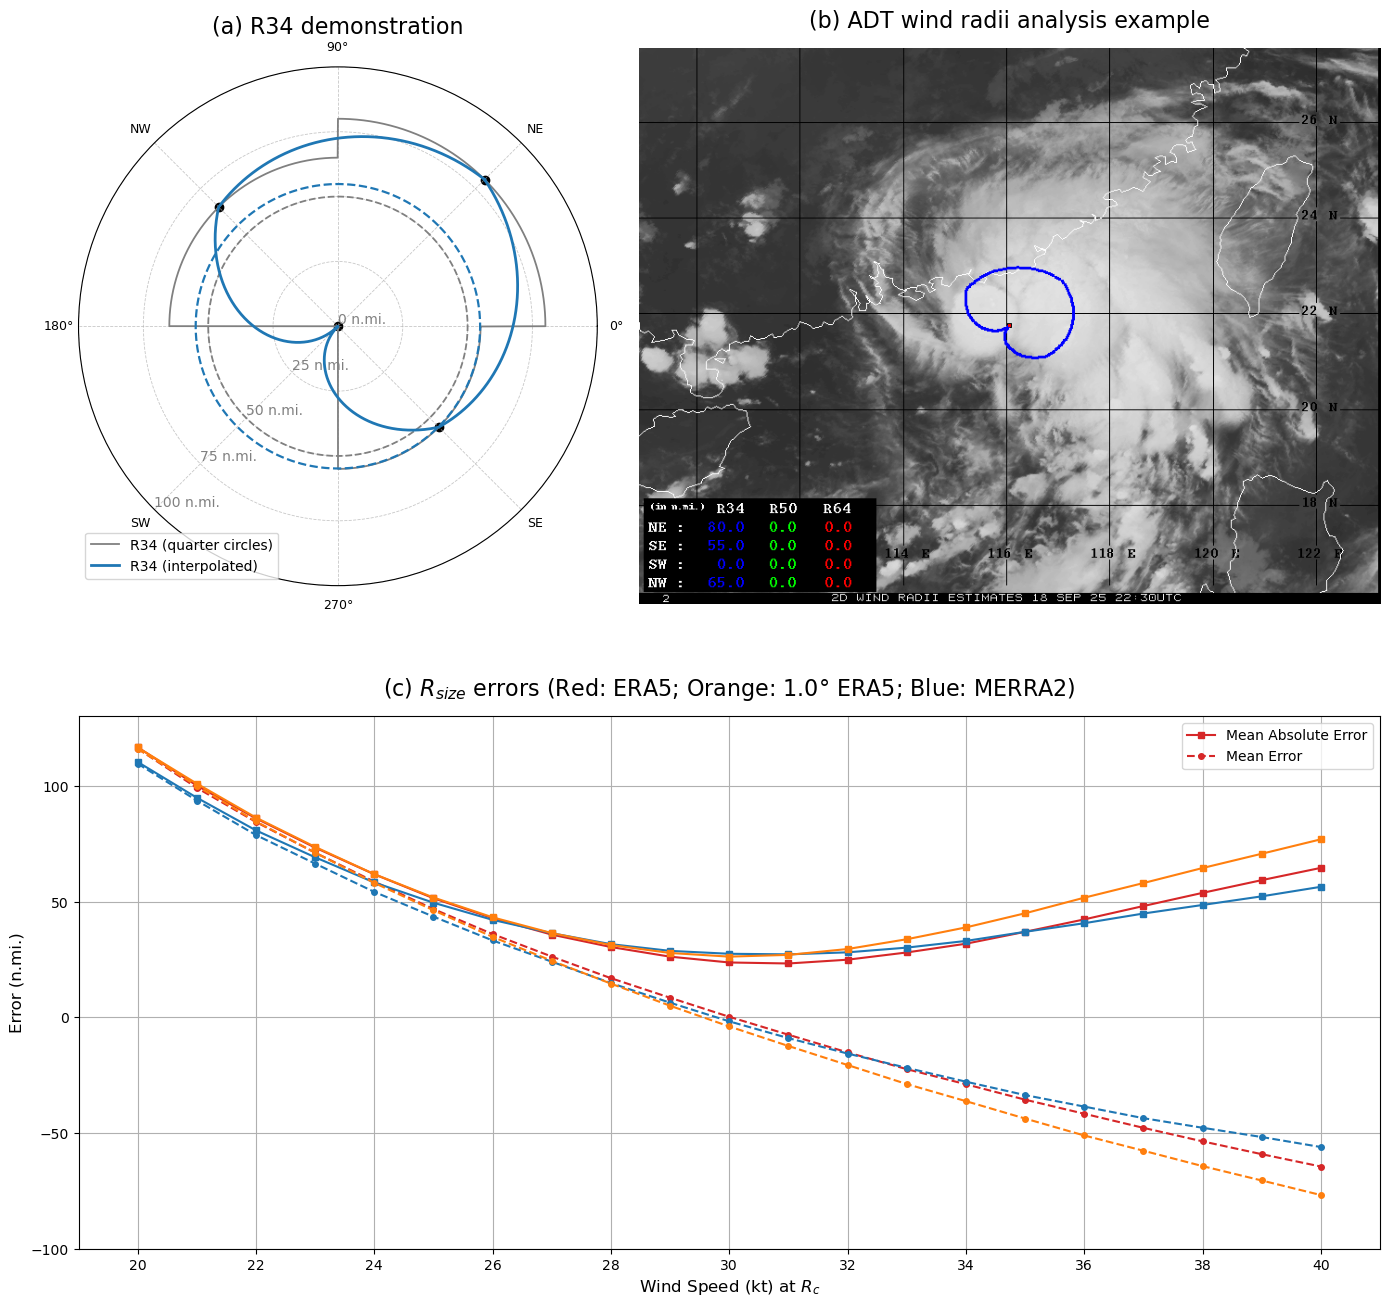

In [ ]:
# Plot figure 2
example_fig = '../figures/23W-2DWIND.gif'
# Display the image from the GIF file
fig=plt.figure(figsize=(14, 14))
gs = fig.add_gridspec(2,2,height_ratios=[1.5,1],width_ratios=[0.7,1])
ax1 = fig.add_subplot(gs[0, 0],polar=True)
angles = np.linspace(0, 2 * np.pi, 361, endpoint=True)+np.pi/4
angles2 = np.linspace(0, 2 * np.pi, 3610, endpoint=True)+np.pi/4
quadrant_bounds = np.array([0, np.pi/2, np.pi, 3*np.pi/2, 2*np.pi])+np.pi/4
radii = [80, 65, 0, 55, 80]
# Interpolate using numpy.interp
r30_interp = np.interp(angles, quadrant_bounds, radii)
r30_uniform_quadrants = np.piecewise(angles2, 
                                 [ (angles2 >= quadrant_bounds[i]-np.pi/4) & (angles2 < quadrant_bounds[i+1]-np.pi/4) for i in range(len(quadrant_bounds)-1)],
                                 radii)
r30_uniform_circular = np.full_like(angles, np.mean(radii[:-1]))
r30_uniform_circular_adj = np.full_like(angles, 54.83)
ax1.plot(angles2, r30_uniform_quadrants, label='R34 (quarter circles)', c='grey',lw=1.3)
ax1.plot(angles, r30_uniform_circular, c='grey',ls='--',lw=1.3)
ax1.plot(angles, r30_interp, label='R34 (interpolated)',lw=2)
ax1.plot(angles, r30_uniform_circular_adj, c='tab:blue',ls='--',lw=1.6)
ax1.scatter([np.pi/4,3*np.pi/4,5*np.pi/4,7*np.pi/4], [80, 65, 0, 55], c='k',marker='o')
ax1.set_theta_zero_location('E')
ax1.set_theta_direction(1)
r_ticks = [0, 25, 50, 75, 100]
deg_ticks = np.arange(0, 360, 45)  # every 45 degrees
# set angular tick positions and labels, adding NE/SE/SW/NW at the 45°-intervals
tick_angles = np.deg2rad(deg_ticks)
label_map = {45: 'NE', 135: 'NW', 225: 'SW', 315: 'SE'}
tick_labels = [label_map.get(int(d), f"{int(d)}°") for d in deg_ticks]
ax1.set_xticks(tick_angles)
ax1.set_xticklabels(tick_labels, fontsize=10)
ax1.set_ylim(0, max(r_ticks))                    # set radial limit
ax1.set_rticks(r_ticks)                          # set radial tick positions
ax1.set_yticklabels([f"{v} n.mi." for v in r_ticks], fontsize=10, color='gray')  # custom labels
ax1.set_rlabel_position(225)                     # move radial labels to avoid overlap with plot
ax1.grid(True, which='both', linestyle='--', linewidth=0.6, alpha=0.7)
ax1.tick_params(axis='x', labelsize=9)           # angle labels size
ax1.set_title('(a) R34 demonstration', fontsize=16)
ax1.legend(loc='lower left', fontsize=10)

ax2 = fig.add_subplot(gs[0, 1])
img08w=plt.imread(example_fig)
# Then create a figure to display a static frame with caption
ax2.axis('off')
ax2.imshow(img08w)
ax2.set_title('(b) ADT wind radii analysis example', fontsize=16,pad=15)

wind_speed_knots=np.arange(20,41,1)
ax3 = fig.add_subplot(gs[1, :])
ax3.plot(wind_speed_knots,maelste, label='Mean Absolute Error', marker='s',c='tab:red',ms=4)
ax3.plot(wind_speed_knots,melste, label='Mean Error', marker='o',c='tab:red',linestyle='--',ms=4)
ax3.plot(wind_speed_knots,maelstm, marker='s',c='tab:blue',ms=4)
ax3.plot(wind_speed_knots,melstm, marker='o',c='tab:blue',linestyle='--',ms=4)
ax3.plot(wind_speed_knots,maelst, marker='s',c='tab:orange',ms=4)
ax3.plot(wind_speed_knots,melst, marker='o',c='tab:orange',linestyle='--',ms=4)
ax3.set_xticks(np.arange(20,42,2))
plt.xlabel('Wind Speed (kt) at $R_c$',fontsize=12)
plt.ylabel('Error (n.mi.)',fontsize=12)
plt.ylim(-100,130)
plt.title('(c) $R_{size}$ errors (Red: ERA5; Orange: 1.0$\degree$ ERA5; Blue: MERRA2)',fontsize=16,pad=15)
plt.grid(True)
plt.legend(fontsize=10)
plt.tight_layout()
plt.savefig('../figures/figure2.jpg',dpi=500,bbox_inches='tight')
